In [1]:
from timescale import TimescaleDBManager
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine
from sqlalchemy import text 
from matplotlib.backends.backend_pdf import PdfPages
import sys
import json
import warnings
import traceback
import random
from collections import Counter

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
import sys
print(sys.executable)

C:\Python314\python.exe


In [3]:
load_dotenv()
user_env        = os.getenv("USER_DB")
pass_env        = os.getenv("PASS_DB")
host_env        = os.getenv("HOST_DB", "localhost")
port_env        = os.getenv("DB_PORT_EXPOSED", "5432")
db_env          = os.getenv("NAME_DB", "tfm_db")
FOLDER_SALIDA   = os.getenv("FOLDER_SALIDA")

SEED            = os.getenv("SEED")

db = TimescaleDBManager(
    user=user_env,
    password=pass_env,
    host=host_env,
    port=port_env,
    dbname=db_env
)
db.conectar()
conexion_postgresql = db.connection

#esto es para usar una conexion postgrews para pandas que da un warning indicando que solo esta testeado para sqlalchemy
engine = create_engine(f'postgresql+psycopg2://{user_env}:{pass_env}@{host_env}:{port_env}/{db_env}')

🔌 [OK] Conexión establecida con TimescaleDB.


In [4]:
SQL='select distinct(metric_name) from metricas'
df_metric_name = pd.read_sql(SQL, engine)
lista_metric_name=df_metric_name['metric_name'].to_list()


In [5]:
SQL='select distinct(execution_name) from metricas'
df_metric_name = pd.read_sql(SQL, engine)
lista_execution_name=df_metric_name['execution_name'].to_list()

# <span style="color:#2ca02c">1. Analisis de cantidad de datos por ejecucion (execution_name)</span>

In [6]:
# 1. Obtenemos el conteo de registros por ejecución
SQL = 'SELECT execution_name, COUNT(*) AS total_registros FROM metricas GROUP BY execution_name'
df_counts = pd.read_sql(SQL, engine)

# 2. Definimos el umbral (el máximo de registros encontrados)
umbral = df_counts['total_registros'].max()

# 3. Filtramos: seleccionamos las ejecuciones con MENOS registros que el máximo
df_anomalias = df_counts[df_counts['total_registros'] < umbral].copy()

# 4. Añadimos la columna de 'faltante'
df_anomalias['faltante_para_maximo'] = (umbral - df_anomalias['total_registros']).astype(int)

# 5. Añadimos la columna 'max_registros' al final
df_anomalias['max_registros'] = umbral

# 6. Ordenamos y generamos la lista
df_anomalias = df_anomalias.sort_values(by='total_registros', ascending=True)
lista_ejecuciones_descartadas = df_anomalias['execution_name'].tolist()

print(f"📋 Ejecuciones con menos registros que el máximo ({umbral:.0f}):\n")
df_anomalias

📋 Ejecuciones con menos registros que el máximo (83420):



,execution_name,total_registros,faltante_para_maximo,max_registros
1574,light-oauth2-data-1722478279.tar,9215,74205,83420
538,light-oauth2-data-1722474696.tar,15035,68385,83420
1362,light-oauth2-data-1722471120.tar,23765,59655,83420
1412,light-oauth2-data-1722467564.tar,39770,43650,83420


In [ ]:
with open(f'{FOLDER_SALIDA}/lista_ejecuciones_descartadas.json', "w", encoding="utf-8") as f:
    json.dump(lista_ejecuciones_descartadas, f, ensure_ascii=False, indent=4)

Sólo 4 ejecuciones tienen una cantidad diferente de datos. Para analizar utiliar los datos en entrenamiento y predicciones puede ser conveniente no contar con esas ejecuciones.

## <span style="color:#2ca02c">2. Analisis de cantidad de datos por metric_name</span>

In [7]:
SQL='select metric_name,count(*) from metricas group by metric_name'
df_counts = pd.read_sql(SQL, engine)


#1.convertir el resutado a dataframe
df_counts['count'] = df_counts['count'].astype(int)

# 2. Calcular la frecuencia y cambiar el nombre de la serie para evitar colisiones
frecuencias = df_counts['count'].value_counts()
frecuencias.name = 'Frecuencia Absoluta'

# 3. Ahora sí hacemos el reset_index de forma segura
tabla_valores_unicos = frecuencias.sort_index().reset_index()

# 4. Renombrar la columna que Pandas saca del índice viejo para que quede impecable
tabla_valores_unicos.columns = ['N', 'Frecuencia Absoluta']

# 5. Calcular el porcentaje que representa sobre el total
total_ejecuciones = len(df_counts)
tabla_valores_unicos['Porcentaje (%)'] = (
    (tabla_valores_unicos['Frecuencia Absoluta'] / total_ejecuciones) * 100
).map('{:.2f}%'.format)

# 6. Mostrar la tabla compacta y real
print(f"📋 RESUMEN DE VALORES ÚNICOS (Total Ejecuciones Analizadas: {total_ejecuciones})\n")
tabla_valores_unicos

📋 RESUMEN DE VALORES ÚNICOS (Total Ejecuciones Analizadas: 485)



,N,Frecuencia Absoluta,Porcentaje (%)
0,298085,485,100.00%


Todas las métricas tienen la misma cantidad de datos

# <span style="color:#2ca02c">3. Revisión de nulos</span>

In [8]:
SQL = """
SELECT 
    COUNT(*) AS total_registros,
    COUNT(*) - COUNT(metric_value) AS nulos_en_valores,
    COUNT(*) - COUNT(label) AS nulos_en_etiquetas,
    COUNT(*) - COUNT(time) AS nulos_en_tiempo,
    COUNT(*) - COUNT(grupo) AS nulos_en_grupo,
    COUNT(*) - COUNT(job) AS nulos_en_job
FROM metricas;
"""

df_nulos = pd.read_sql(SQL, engine)
df_nulos

#result=db.ejecutar_select_generica(SQL)
#print(result)

,total_registros,nulos_en_valores,nulos_en_etiquetas,nulos_en_tiempo,nulos_en_grupo,nulos_en_job
0,144571225,0,0,0,67665295,0


No tenemos nulos en tiempo, label, metric_value ni job. En el campo grupo la mitad de los datos es nulo.

In [9]:
metrica='prometheus_tsdb_wal_fsync_duration_seconds'

SQL = f"""
    SELECT 
        metric_name, 
        metric_value, 
        COUNT(*) AS frecuencia
    FROM metricas
    WHERE metric_name='{metrica}'
    GROUP BY metric_name, metric_value
    ORDER BY metric_name, frecuencia DESC;
"""

df_cardinalidad_valores = pd.read_sql(SQL, engine)
df_cardinalidad_valores



,metric_name,metric_value,frecuencia
0,prometheus_tsdb_wal_fsync_duration_seconds,NaN,298085


# <span style="color:#2ca02c">4. Revision de datos de cada métrica</span>

In [10]:

SQL = f"""SELECT 
            metric_name,
            COUNT(*) AS total_registros,
            SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) AS N_nan,
            ROUND(100.0 * SUM(CASE WHEN  metric_value='nan' THEN 1 ELSE 0 END) / COUNT(*), 2) AS PERC_nan
        FROM metricas
        GROUP BY metric_name
        HAVING SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) > 0
        ORDER BY metric_name,PERC_nan DESC;
    """
df=pd.read_sql(SQL, engine)
df

,metric_name,total_registros,n_nan,perc_nan
0,prometheus_engine_query_duration_seconds,298085,24045,8.07
1,prometheus_rule_evaluation_duration_seconds,298085,298085,100.00
2,prometheus_rule_group_duration_seconds,298085,298085,100.00
3,prometheus_sd_consul_rpc_duration_seconds,298085,298085,100.00
4,prometheus_sd_file_scan_duration_seconds,298085,298085,100.00
5,prometheus_sd_kuma_fetch_duration_seconds,298085,298085,100.00
6,prometheus_target_sync_length_seconds,298085,88064,29.54
7,prometheus_tsdb_wal_fsync_duration_seconds,298085,298085,100.00


In [11]:
lista_metricas_descartadas_NaN = df[df['perc_nan']==100.0]['metric_name'].to_list()
lista_metricas_descartadas_NaN

['prometheus_rule_evaluation_duration_seconds',
 'prometheus_rule_group_duration_seconds',
 'prometheus_sd_consul_rpc_duration_seconds',
 'prometheus_sd_file_scan_duration_seconds',
 'prometheus_sd_kuma_fetch_duration_seconds',
 'prometheus_tsdb_wal_fsync_duration_seconds']

## <span style="color:#2ca02c">4.1. Revision de NaN en prometheus_engine_query_duration_seconds</spain>

In [52]:
metrica='prometheus_engine_query_duration_seconds'
SQL = f"""SELECT 
            execution_name,
            COUNT(*) AS total_registros,
            SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) AS N_nan,
            ROUND(100.0 * SUM(CASE WHEN  metric_value='nan' THEN 1 ELSE 0 END) / COUNT(*), 2) AS PERC_nan
        FROM metricas
        WHERE metric_name='{metrica}'
        GROUP BY execution_name;
    """
df=pd.read_sql(SQL, engine)
df

,execution_name,total_registros,n_nan,perc_nan
0,light-oauth2-data-1719592986.tar,172,14,8.14
1,light-oauth2-data-1719594842.tar,172,14,8.14
2,light-oauth2-data-1719598443.tar,172,14,8.14
3,light-oauth2-data-1719602043.tar,172,14,8.14
4,light-oauth2-data-1719605644.tar,172,14,8.14
...,...,...,...,...
1731,light-oauth2-data-1725855291.tar,172,13,7.56
1732,light-oauth2-data-1725858922.tar,172,14,8.14
1733,light-oauth2-data-1725862507.tar,172,14,8.14
1734,light-oauth2-data-1725866154.tar,172,13,7.56


In [13]:
metrica='prometheus_engine_query_duration_seconds'
SQL = f"""SELECT 
            label,
            COUNT(*) AS total_registros,
            SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) AS N_nan,
            ROUND(100.0 * SUM(CASE WHEN  metric_value='nan' THEN 1 ELSE 0 END) / COUNT(*), 2) AS PERC_nan
        FROM metricas
        WHERE metric_name='{metrica}'
        GROUP BY label;
    """
df=pd.read_sql(SQL, engine)
df

,label,total_registros,n_nan,perc_nan
0,invalid_code_verifier_format_PKCE_400,5196,0,0.00
1,access_token_client_id_not_found_404,5196,0,0.00
2,update_client_400_clientProfile,5205,0,0.00
3,access_token_authorization_form_401,5196,0,0.00
4,code_challenge_too_long_pkce_400,5196,0,0.00
5,authorization_code_invalid_password_401,5199,0,0.00
6,access_token_illegal_grant_type_400,5196,0,0.00
7,authorization_code_invalid_client_id_404,5199,0,0.00
8,update_password_400_not_match,5196,0,0.00
9,register_user_400_no_password,5196,0,0.00


La metrica='prometheus_engine_query_duration_seconds' tienen NaN en todos los datos etiquetados como correct, por lo que no sirve para usar algoritmos de deteccion de anomalias ya que no tenemos datos "normales" de esta métrica.

In [14]:
lista_metricas_descartadas_NaN.append('prometheus_engine_query_duration_seconds')

## <span style="color:#2ca02c">4.2. Revision de NaN en prometheus_target_sync_length_seconds</spain>

In [15]:
metrica='prometheus_target_sync_length_seconds'
SQL = f"""SELECT 
            execution_name,
            COUNT(*) AS total_registros,
            SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) AS N_nan,
            ROUND(100.0 * SUM(CASE WHEN  metric_value='nan' THEN 1 ELSE 0 END) / COUNT(*), 2) AS PERC_nan
        FROM metricas
        WHERE metric_name='{metrica}'
        GROUP BY execution_name;
    """
df=pd.read_sql(SQL, engine)
df

,execution_name,total_registros,n_nan,perc_nan
0,light-oauth2-data-1719592986.tar,172,47,27.33
1,light-oauth2-data-1719594842.tar,172,47,27.33
2,light-oauth2-data-1719598443.tar,172,47,27.33
3,light-oauth2-data-1719602043.tar,172,47,27.33
4,light-oauth2-data-1719605644.tar,172,48,27.91
...,...,...,...,...
1731,light-oauth2-data-1725855291.tar,172,56,32.56
1732,light-oauth2-data-1725858922.tar,172,62,36.05
1733,light-oauth2-data-1725862507.tar,172,57,33.14
1734,light-oauth2-data-1725866154.tar,172,65,37.79


In [53]:
metrica='prometheus_target_sync_length_seconds'
SQL = f"""SELECT 
            label,
            COUNT(*) AS total_registros,
            SUM(CASE WHEN metric_value='nan' THEN 1 ELSE 0 END) AS N_nan,
            ROUND(100.0 * SUM(CASE WHEN  metric_value='nan' THEN 1 ELSE 0 END) / COUNT(*), 2) AS PERC_nan
        FROM metricas
        WHERE metric_name='{metrica}'
        GROUP BY label;
    """
df=pd.read_sql(SQL, engine)
df

,label,total_registros,n_nan,perc_nan
0,invalid_code_verifier_format_PKCE_400,5196,688,13.24
1,access_token_client_id_not_found_404,5196,0,0.00
2,update_client_400_clientProfile,5205,0,0.00
3,access_token_authorization_form_401,5196,3,0.06
4,code_challenge_too_long_pkce_400,5196,17,0.33
5,authorization_code_invalid_password_401,5199,0,0.00
6,access_token_illegal_grant_type_400,5196,0,0.00
7,authorization_code_invalid_client_id_404,5199,0,0.00
8,update_password_400_not_match,5196,5196,100.00
9,register_user_400_no_password,5196,5196,100.00


La métrica='prometheus_target_sync_length_seconds' no tiene NaN en datos etiquetados como correctos, hay anomalías que tienen todos los valores de esta métrica NaN.

Se sustituira los NaN por valores medios y se creara una caracteristica que sera 1 si hay NaN y 0 si no lo es. Esta caracteristica parece varlosa para detectar algunas de las anomalias.

In [17]:
with open(f'result/lista_metricas_descartadas_NaN.json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_descartadas_NaN, f, ensure_ascii=False, indent=4)

# <span style="color:#2ca02c">5. Revision de datos de cada métrica</span>

In [18]:

una_ejecucion = 'light-oauth2-data-1725524098.tar'


SQL_check = f"""
SELECT COUNT(*) as muestras_metrica_ejecucion
FROM metricas
WHERE execution_name = '{una_ejecucion}'
  AND metric_name = 'go_gc_duration_seconds';
"""

df_var = pd.read_sql(SQL_check, engine)
df_var

,muestras_metrica_ejecucion
0,172


In [19]:
lista_metricas_filtradas=lista_metric_name.copy()
lista_metricas_filtradas = [item for item in lista_metricas_filtradas if item not in lista_metricas_descartadas_NaN]



In [20]:
len(lista_metricas_filtradas)

478

In [21]:
# Tu lista de métricas filtradas

# Convertimos la lista a una tupla (es el formato que espera SQL para el operador IN)
tuple_metricas = tuple(lista_metricas_filtradas)

# Usamos %s como marcador de posición (el driver de SQL hará el escape correcto)
# Nota: Si la lista solo tiene un elemento, la tupla debe definirse como (elemento,)
SQL = """
SELECT 
    metric_name,
    COUNT(*) AS N_muestras,
    MIN(metric_value) AS MIN,
    PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY metric_value) AS Q1,
    PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY metric_value) AS Q2,
    PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY metric_value) AS Q3,
    MAX(metric_value) AS MAX,
    STDDEV(metric_value) AS STD_DEV
FROM 
    metricas
WHERE 
    metric_name IN %(metricas)s
GROUP BY 
    metric_name;
"""

# Lanzamos la consulta pasando el diccionario de parámetros
df_resumen_estadistico = pd.read_sql_query(SQL, engine, params={'metricas': tuple_metricas})
df_resumen_estadistico

,metric_name,n_muestras,min,q1,q2,q3,max,std_dev
0,go_gc_duration_seconds,298085,0.000050,0.001177,0.002345,0.004553,0.025355,0.003533
1,go_gc_duration_seconds_count,298085,5.000000,314.000000,756.000000,1157.000000,7526.000000,475.301000
2,go_gc_duration_seconds_sum,298085,0.000170,0.031020,0.069503,0.103603,2.241065,0.054989
3,go_goroutines,298085,31.000000,33.000000,33.000000,33.000000,47.000000,0.529508
4,go_info,298085,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
...,...,...,...,...,...,...,...,...
473,scrape_duration_seconds,298085,0.002548,0.003125,0.003599,0.004656,0.093296,0.001699
474,scrape_samples_post_metric_relabeling,298085,452.000000,475.000000,475.000000,475.000000,475.000000,6.263485
475,scrape_samples_scraped,298085,452.000000,475.000000,475.000000,475.000000,475.000000,6.263485
476,scrape_series_added,298085,0.000000,0.000000,0.000000,0.000000,23.000000,1.750109


In [22]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_resumen_estadistico)

,metric_name,n_muestras,min,q1,q2,q3,max,std_dev
0,go_gc_duration_seconds,298085,4.974600e-05,1.177333e-03,2.344854e-03,4.553375e-03,2.535489e-02,3.533145e-03
1,go_gc_duration_seconds_count,298085,5.000000e+00,3.140000e+02,7.560000e+02,1.157000e+03,7.526000e+03,4.753010e+02
2,go_gc_duration_seconds_sum,298085,1.702370e-04,3.102036e-02,6.950255e-02,1.036026e-01,2.241065e+00,5.498943e-02
3,go_goroutines,298085,3.100000e+01,3.300000e+01,3.300000e+01,3.300000e+01,4.700000e+01,5.295083e-01
4,go_info,298085,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
5,go_memstats_alloc_bytes,298085,1.297302e+07,1.828640e+07,2.152126e+07,2.504211e+07,4.348970e+07,5.188229e+06
6,go_memstats_alloc_bytes_total,298085,2.417214e+07,4.191865e+09,1.027846e+10,1.624335e+10,1.306203e+11,6.968208e+09
7,go_memstats_buck_hash_sys_bytes,298085,1.455307e+06,1.528171e+06,1.569547e+06,1.595691e+06,1.716363e+06,4.593345e+04
8,go_memstats_frees_total,298085,6.184800e+04,1.912456e+06,4.525423e+06,7.100929e+06,5.558204e+07,3.019577e+06
9,go_memstats_gc_sys_bytes,298085,4.551368e+06,4.826616e+06,4.849312e+06,4.871792e+06,6.155024e+06,5.628279e+04


In [23]:
df_resumen_estadistico.to_parquet(f'{FOLDER_SALIDA}/resumen_estadistico.parquet', index=False,engine='fastparquet')

In [24]:
df_resumen_estadistico = pd.read_parquet(f'{FOLDER_SALIDA}/resumen_estadistico.parquet', engine='fastparquet')

In [62]:
metricas_con_std_dev_nulo     = df_resumen_estadistico['std_dev']==0
df_metricas_filtradas = df_resumen_estadistico[~metricas_con_std_dev_nulo].reset_index(drop=True)
lista_metricas_con_std_dev_nulo = df_resumen_estadistico.loc[metricas_con_std_dev_nulo, 'metric_name'].tolist()

In [65]:
with open(f'result/lista_metricas_con_std_dev_nulo.json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_con_std_dev_nulo, f, ensure_ascii=False, indent=4)

In [26]:
df_metricas_filtradas

,metric_name,n_muestras,min,q1,q2,q3,max,std_dev
0,go_gc_duration_seconds,298085,4.974600e-05,1.177333e-03,2.344854e-03,4.553375e-03,2.535489e-02,3.533145e-03
1,go_gc_duration_seconds_count,298085,5.000000e+00,3.140000e+02,7.560000e+02,1.157000e+03,7.526000e+03,4.753010e+02
2,go_gc_duration_seconds_sum,298085,1.702370e-04,3.102036e-02,6.950255e-02,1.036026e-01,2.241065e+00,5.498943e-02
3,go_goroutines,298085,3.100000e+01,3.300000e+01,3.300000e+01,3.300000e+01,4.700000e+01,5.295083e-01
4,go_memstats_alloc_bytes,298085,1.297302e+07,1.828640e+07,2.152126e+07,2.504211e+07,4.348970e+07,5.188229e+06
...,...,...,...,...,...,...,...,...
151,prometheus_tsdb_wal_storage_size_bytes,298085,6.276900e+04,4.648580e+05,8.575600e+05,1.250033e+06,2.915738e+07,7.968100e+05
152,scrape_duration_seconds,298085,2.548499e-03,3.124508e-03,3.598722e-03,4.656313e-03,9.329599e-02,1.698712e-03
153,scrape_samples_post_metric_relabeling,298085,4.520000e+02,4.750000e+02,4.750000e+02,4.750000e+02,4.750000e+02,6.263485e+00
154,scrape_samples_scraped,298085,4.520000e+02,4.750000e+02,4.750000e+02,4.750000e+02,4.750000e+02,6.263485e+00


In [27]:
lista_metricas_filtadas=df_metricas_filtradas['metric_name'].to_list()
df_metricas_filtradas.to_parquet(f'{FOLDER_SALIDA}/df_metricas_filtradas.parquet', index=False,engine='fastparquet')

In [28]:
with open(f'result/lista_metricas_filtradas.json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_filtadas, f, ensure_ascii=False, indent=4)

In [29]:
# 1. Configuración de estilo y limpieza de avisos
sns.set_theme(style="whitegrid")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

# Inicializamos la estructura para guardar las métricas sin variación
metricas_estaticas = set()

nombre_pdf = "result/informe_estructurado_metricas.pdf"
total_metricas = len(lista_metricas_filtadas)

print(f"🚀 Iniciando exportación masiva a {nombre_pdf}...")

# 2. Abrimos el contexto del PDF
with PdfPages(nombre_pdf) as pdf:
    
    for i, una_metrica in enumerate(lista_metricas_filtadas, 1):
        
        # 🚀 MENSAJE INTERACTIVO: Muestra el progreso actual sobreescribiendo la misma línea
        # Limitamos visualmente el nombre de la métrica a 45 caracteres para mantener limpia la consola
        sys.stdout.write(f"\r🔄 [{i}/{total_metricas}] Procesando: {una_metrica[:45]}...".ljust(80))
        sys.stdout.flush()
        
        # Query para traer los datos de la métrica actual
        SQL = f"""
        SELECT metric_value, label 
        FROM metricas 
        WHERE metric_name = '{una_metrica}';
        """
        
        try:
            df_var = pd.read_sql(text(SQL), engine)
            
            # Saltamos si la métrica está vacía
            if df_var.empty:
                continue
                
            df_var['metric_value'] = df_var['metric_value'].astype(float)
            df_var['label'] = df_var['label'].astype(str)

            # DETECCIÓN DE MÉTRICAS INVARIANTES:
            # Si todos los valores de la columna son idénticos, la guardamos 
            if df_var['metric_value'].nunique() <= 1:
                metricas_estaticas.add(una_metrica)
                #continue

            # Mapeo binario para el Histograma (correct vs el resto)
            df_var['label_binaria'] = df_var['label'].apply(lambda x: 'correct' if x == 'correct' else 'anomaly')

            orden_boxplot = list(df_var['label'].unique())

            # 3. Creamos la figura optimizada para el folio
            fig, axes = plt.subplots(2, 1, figsize=(11, 16), gridspec_kw={'height_ratios': [1, 3]})

            # --- GRÁFICO 1: HISTOGRAMA BINARIO (Arriba) ---
            sns.histplot(
                data=df_var, 
                x='metric_value', 
                hue='label_binaria',  
                hue_order=['correct', 'anomaly'],
                palette={'correct': '#2ecc71', 'anomaly': '#e74c3c'}, 
                kde=True, 
                ax=axes[0],
                element='step',
                stat='density',  
                common_norm=False,
                legend=True  
            )
            axes[0].set_title('Distribución Comparativa Binaria (Histograma)', fontsize=12, fontweight='bold')
            axes[0].set_xlabel('Valor de la Métrica')
            axes[0].set_ylabel('Densidad')

            # --- GRÁFICO 2: BOXPLOT MULTI-ETIQUETA ORDENADO (Abajo) ---
            sns.boxplot(
                data=df_var, 
                x='metric_value', 
                y='label',         
                order=orden_boxplot,  
                orient='h',
                palette='tab20', 
                ax=axes[1],
                hue='label',
                legend=False,
                width=0.7,          
                fliersize=3
            )
            axes[1].set_title('Dispersión Detallada por Escenario / Ataque', fontsize=12, fontweight='bold')
            axes[1].set_xlabel('Valor de la Métrica')
            axes[1].set_ylabel('Tipo de Escenario (Label)')
            axes[1].tick_params(axis='y', labelsize=8)

            # Título de la página actual
            fig.suptitle(f"📊 [Métrica {i}] ANÁLISIS DETALLADO: {una_metrica.upper()}", fontsize=14, fontweight='bold', y=1.01)
            
            plt.tight_layout()
            
            # Guardamos la página en el PDF y liberamos memoria
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
            

    
        except Exception as e:
            error_details = traceback.format_exc()
            fig_err, ax_err = plt.subplots(figsize=(11, 8.5))
            fig_err.suptitle(f"⚠️ ERROR EN MÉTRICA: {una_metrica.upper()}", fontsize=14, fontweight='bold', color='darkred')
            ax_err.text(0.05, 0.95, f"Ocurrió un error al procesar:\n{str(e)}\n\nDetalle técnico (Traceback):", 
                        fontsize=10, fontweight='bold', va='top', transform=ax_err.transAxes)
            ax_err.text(0.05, 0.85, error_details, fontsize=8, va='top', family='monospace', transform=ax_err.transAxes)         
            ax_err.axis('off')
            
            pdf.savefig(fig_err, bbox_inches='tight')
            plt.close(fig_err)
            
            print(f"\n❌ Métrica {una_metrica} falló. Error registrado en el PDF.")

# Un salto de línea final para limpiar la consola al terminar el bucle
print("\n")
print(f"🎉 ¡Hecho! El archivo '{nombre_pdf}' se ha guardado correctamente.")
print(f"🚫 Lista completa de métricas invariantes detectadas: {list(metricas_estaticas)}")

🚀 Iniciando exportación masiva a result/informe_estructurado_metricas.pdf...
🔄 [156/156] Procesando: scrape_series_added...                                 

🎉 ¡Hecho! El archivo 'result/informe_estructurado_metricas.pdf' se ha guardado correctamente.
🚫 Lista completa de métricas invariantes detectadas: ['node_memory_VmallocTotal_bytes', 'node_timex_tick_seconds', 'node_os_version']


Estos boxplot confirman que las pruebas se se hacen siempre igual, primero el tramo sin anomalias y luego todas las anomalias en el mismo orden, aunque  parece que las pruebas no duran exactamente lo mismo y los outliers que aparecen en los boxplots indican que algunas pruebas se alargan en alguna situacion o que ha alguna ejecución anñomala

In [157]:

una_metrica = "PROMETHEUS_TSDB_WAL_STORAGE_SIZE_BYTES" # O la que quieras probar
una_ejecucion = "light-oauth2-data-1725524098.tar"

# 1. Traemos los datos de una ejecución concreta ordenados por tiempo
SQL = f"""
SELECT time, metric_value 
FROM metricas 
WHERE execution_name = '{una_ejecucion}' 
  AND metric_name = '{una_metrica}'
ORDER BY time ASC;
"""

df_test = pd.read_sql(text(SQL), engine)
df_test['metric_value'] = df_test['metric_value'].astype(float)

# 2. Calculamos la diferencia entre cada fila y la anterior (v_actual - v_anterior)
# La primera fila dará NaN, así que la eliminamos para no alterar el test
diferencias = df_test['metric_value'].diff().dropna()

# 3. VEREDICTO MATEMÁTICO
# Si todas las diferencias son mayores o iguales a cero (>= 0), es monótona creciente
es_monotona = (diferencias >= 0).all()

print(f"📊 Análisis de monotonía para: {una_metrica}")
print(f"¿Es estrictamente monótona creciente en esta ejecución?: {'SÍ, es un Contador (Counter) ✅' if es_monotona else 'NO, es un Indicador (Gauge) ❌'}")

# Si no es monótona, podemos ver cuántas veces ha bajado de valor
if not es_monotona:
    caidas = diferencias[diferencias < 0]
    print(f"   ➔ El valor disminuyó {len(caidas)} veces durante la simulación.")
    print(f"   ➔ La mayor caída registrada fue de {caidas.min()} unidades.")

📊 Análisis de monotonía para: PROMETHEUS_TSDB_WAL_STORAGE_SIZE_BYTES
¿Es estrictamente monótona creciente en esta ejecución?: SÍ, es un Contador (Counter) ✅


In [32]:
# Lista para almacenar los diccionarios con los resultados de cada métrica
resultados_monotonia = []

print(f"⏳ Auditando monotonía para las {len(lista_metricas_filtadas)} métricas filtradas...")

# 1. Bucle que recorre únicamente tu lista de métricas limpias
for i, metrica in enumerate(lista_metricas_filtadas):
    texto_progreso = f'Calculando monotonia de métrica ({metrica})'
    print(f"\r{texto_progreso}".ljust(100), end='', flush=True)
    
    # Query optimizada: Traemos el valor y la ejecución ordenados cronológicamente
    SQL = f"""
    SELECT execution_name, metric_value 
    FROM metricas 
    WHERE metric_name = '{metrica}'
    ORDER BY execution_name, time ASC;
    """
    
    df_m = pd.read_sql(text(SQL), engine)
    
    if df_m.empty:
        continue
        
    df_m['metric_value'] = df_m['metric_value'].astype(float)
    
    # 2. Agrupamos por ejecución y calculamos la diferencia con el registro anterior
    # Usamos .diff() dentro de cada grupo para no mezclar ejecuciones distintas
    df_m['diferencia'] = df_m.groupby('execution_name')['metric_value'].diff()
    
    # Eliminamos los NaNs que genera el .diff() en la primera fila de cada ejecución
    df_m_limpio = df_m.dropna(subset=['diferencia'])
    
    # 3. Contamos ejecuciones totales implicadas en esta métrica
    lista_ejecuciones = df_m['execution_name'].unique()
    total_ejecuciones = len(lista_ejecuciones)
    
    # 4. Evaluamos cuáles de esas ejecuciones son monótonas
    # Una ejecución es monótona si TODAS sus diferencias son mayores o iguales a 0
    ejecuciones_monotonas = 0
    for ejecucion in lista_ejecuciones:
        df_ejec = df_m_limpio[df_m_limpio['execution_name'] == ejecucion]
        if (df_ejec['diferencia'] >= 0).all():
            ejecuciones_monotonas += 1
            
    # 5. Guardamos el balance de la métrica actual
    es_monotona_100 = (ejecuciones_monotonas == total_ejecuciones)
    
    resultados_monotonia.append({
        'metric_name': metrica,
        'total_ejecuciones': total_ejecuciones,
        'ejecuciones_monotonas': ejecuciones_monotonas,
        'es_monotona_100': es_monotona_100,
        'clasificacion_tipo': 'Monótona Creciente (Counter) ✅' if es_monotona_100 else 'Variable (Gauge) ❌'
    })
    
    # Pequeño chivato para ver el progreso en el Notebook
    if (i + 1) % 5 == 0 or (i + 1) == len(lista_metricas_filtadas):
        print(f"   ➔ Procesadas {i + 1}/{len(lista_metricas_filtadas)} métricas.")

# 6. Construimos el DataFrame final de resumen
df_resumen_monotonia = pd.DataFrame(resultados_monotonia)

# Ordenamos para tener los contadores (Counters) arriba del todo
df_resumen_monotonia = df_resumen_monotonia.sort_values(by='es_monotona_100', ascending=False).reset_index(drop=True)

print("\n🎉 ¡Auditoría completada con éxito!")
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None, 
                       'display.max_colwidth', None):
    
    display(df_resumen_monotonia)

⏳ Auditando monotonía para las 156 métricas filtradas...
Calculando monotonia de métrica (go_memstats_alloc_bytes)                                             ➔ Procesadas 5/156 métricas.
Calculando monotonia de métrica (go_memstats_heap_alloc_bytes)                                        ➔ Procesadas 10/156 métricas.
Calculando monotonia de métrica (go_memstats_heap_sys_bytes)                                          ➔ Procesadas 15/156 métricas.
Calculando monotonia de métrica (go_memstats_next_gc_bytes)                                           ➔ Procesadas 20/156 métricas.
Calculando monotonia de métrica (go_threads)                                                          ➔ Procesadas 25/156 métricas.
Calculando monotonia de métrica (node_filefd_allocated)                                               ➔ Procesadas 30/156 métricas.
Calculando monotonia de métrica (node_load15)                                                         ➔ Procesadas 35/156 métricas.
Calculando monotonia

,metric_name,total_ejecuciones,ejecuciones_monotonas,es_monotona_100,clasificacion_tipo
0,node_schedstat_timeslices_total,1736,1736,True,Monótona Creciente (Counter) ✅
1,prometheus_http_request_duration_seconds_sum,1736,1736,True,Monótona Creciente (Counter) ✅
2,node_memory_VmallocTotal_bytes,1736,1736,True,Monótona Creciente (Counter) ✅
3,process_virtual_memory_bytes,1736,1736,True,Monótona Creciente (Counter) ✅
4,prometheus_config_last_reload_success_timestamp_seconds,1736,1736,True,Monótona Creciente (Counter) ✅
5,prometheus_engine_query_duration_seconds_count,1736,1736,True,Monótona Creciente (Counter) ✅
6,prometheus_engine_query_duration_seconds_sum,1736,1736,True,Monótona Creciente (Counter) ✅
7,prometheus_engine_query_samples_total,1736,1736,True,Monótona Creciente (Counter) ✅
8,prometheus_http_request_duration_seconds_bucket,1736,1736,True,Monótona Creciente (Counter) ✅
9,prometheus_http_request_duration_seconds_count,1736,1736,True,Monótona Creciente (Counter) ✅


In [33]:
df_resumen_monotonia.to_parquet(f'{FOLDER_SALIDA}/df_resumen_monotonia.parquet', index=False,engine='fastparquet')

In [34]:
lista_metricas_monotonas=df_resumen_monotonia[df_resumen_monotonia['es_monotona_100']]['metric_name'].to_list()

In [35]:
with open(f'result/lista_metricas_monotonas.json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_monotonas, f, ensure_ascii=False, indent=4)

In [36]:
len(lista_metricas_monotonas)

84

In [38]:

# 1. Configuración global de estilos y supresión de alertas
sns.set_theme(style="whitegrid")
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)


nombre_pdf = f"{FOLDER_SALIDA}/analisis_metricas_monotonas_transformadas.pdf"
total_metricas = len(lista_metricas_monotonas)
lista_metricas_monotonas_invariantes=[]

print(f"🚀 Iniciando exportación masiva a {nombre_pdf}...")

# 3. Abrimos el gestor de contexto del PDF
with PdfPages(nombre_pdf) as pdf:
    
    for i, metrica in enumerate(lista_metricas_monotonas, 1):
        
        # Mensaje interactivo de progreso
        sys.stdout.write(f"\r🔄 [{i}/{total_metricas}] Procesando: {metrica[:50]}...".ljust(80))
        sys.stdout.flush()
        
        # 4. Consulta SQL optimizada descartando la primera muestra desestabilizadora
        SQL = f"""
        WITH ordenado AS (
            SELECT 
                time, 
                execution_name, 
                label,
                metric_value::float AS valor_bruto,
                LAG(metric_value::float) OVER (
                    PARTITION BY execution_name 
                    ORDER BY time ASC
                ) AS valor_anterior
            FROM metricas 
            WHERE metric_name = '{metrica}'
        )
        SELECT 
            time,
            execution_name,
            label,
            (valor_bruto - valor_anterior) AS metric_value
        FROM ordenado
        WHERE valor_anterior IS NOT NULL
        ORDER BY execution_name, time ASC;
        """
        
        try:
            df_diff = pd.read_sql(SQL, engine)
            
            if df_diff.empty:
                continue

            if df_diff['metric_value'].std() == 0:
                lista_metricas_monotonas_invariantes.append(f'{metrica}_diff')
            # Agrupamos las etiquetas para el histograma binario (correct vs resto)
            df_diff['label_binaria'] = df_diff['label'].apply(lambda x: 'correct' if x == 'correct' else 'anomaly')
                
            orden_boxplot = list(df_var['label'].unique())

            # 🚀 SOLUCIÓN AL SINGULAR MATRIX:
            # Comprobamos si la columna tiene variabilidad (desviación estándar > 0)
            # Si todos los deltas son 0 (o idénticos), desactivamos el KDE para que no rompa el álgebra lineal.
            tiene_varianza = df_diff['metric_value'].std() > 0

            # 5. Construcción de la figura con la asimetría GridSpec (1:3)
            fig = plt.figure(figsize=(15, 18))
            gs = fig.add_gridspec(2, 1, height_ratios=[1, 3]) 

            ax_hist = fig.add_subplot(gs[0])
            ax_box = fig.add_subplot(gs[1])

            # --- SUBGRÁFICO 1: HISTOGRAMA DE DENSIDAD BINARIO ---
            sns.histplot(
                data=df_diff, 
                x='metric_value', 
                hue='label_binaria',  
                hue_order=['correct', 'anomaly'],
                palette={'correct': '#2ecc71', 'anomaly': '#e74c3c'}, 
                kde=tiene_varianza, # 🚀 DINÁMICO: True si hay varianza, False si los datos son idénticos
                ax=ax_hist,
                element='step',
                stat='density',  
                common_norm=False,
                legend=True  
            )
            ax_hist.set_title(f'Histograma de Densidad Binario\n({metrica}_diff)', fontsize=14, fontweight='bold')
            ax_hist.set_xlabel('Delta (Valor actual - Anterior)', fontsize=12)
            ax_hist.set_ylabel('Densidad', fontsize=12)

            # --- SUBGRÁFICO 2: BOXPLOT HORIZONTAL EXTENDIDO ---
            sns.boxplot(
                data=df_diff, 
                x='metric_value',  
                y='label',         
                order=orden_boxplot,  
                hue='label',          
                legend=False,      
                ax=ax_box,
                palette='tab20'       
            )
            ax_box.set_title(f'Boxplot Horizontal({metrica}_diff)', fontsize=14, fontweight='bold')
            ax_box.set_xlabel('Delta (Valor actual - Anterior)', fontsize=12)
            ax_box.set_ylabel('Fase / Anomalía', fontsize=12)

            ax_box.set_yticklabels(ax_box.get_yticklabels(), fontsize=9.5)

            plt.subplots_adjust(
                hspace=0.25,      
                left=0.28,        
                right=0.95,       
                top=0.94, 
                bottom=0.06
            )

            # 6. Guardamos la figura actual como una página nueva en el PDF
            pdf.savefig(fig)
            plt.close(fig)
        except Exception as e:
            print("")
            print(f"❌ Error procesando la métrica {metrica}: {str(e)}")
            if 'fig' in locals():
                plt.close(fig)

print("\n✨ ¡Proceso completado con éxito! Tu PDF binario y ordenado está listo en: " + nombre_pdf)

🚀 Iniciando exportación masiva a result/analisis_metricas_monotonas_transformadas.pdf...
🔄 [84/84] Procesando: net_conntrack_listener_conn_accepted_total...            
✨ ¡Proceso completado con éxito! Tu PDF binario y ordenado está listo en: result/analisis_metricas_monotonas_transformadas.pdf


In [39]:
len(lista_metricas_monotonas_invariantes)

20

In [39]:
with open(f'result/lista_metricas_diff_invariantes.json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_monotonas_invariantes, f, ensure_ascii=False, indent=4)

In [43]:
len(metricas_con_std_dev_nulo)

478

In [66]:
df_analisis_metricas                     = pd.DataFrame({'metric_name': lista_metric_name})
df_analisis_metricas['std_dev_nulo']     = df_analisis_metricas['metric_name'].isin(lista_metricas_con_std_dev_nulo)
df_analisis_metricas['valores_NAN']      = df_analisis_metricas['metric_name'].isin(lista_metricas_descartadas_NaN)
df_analisis_metricas['metrica_monotona'] = df_analisis_metricas['metric_name'].isin(lista_metricas_monotonas)
df_analisis_metricas['diff_invariante']  = df_analisis_metricas['metric_name'].isin([metrica_diff.replace("_diff", "") for metrica_diff in lista_metricas_monotonas_invariantes])

In [67]:
def clasificar_metrica(row):
    if row['std_dev_nulo']:
        result=''
    elif row['valores_NAN']:
        result=''
    elif not row['metrica_monotona']:
        result='normal'
    elif row['diff_invariante']:
        result=''
    else:
        result='diff'
    return result

def nombre_metrica(row):
    if row['clasificacion']=='normal':
        result=row['metric_name']
    elif row['clasificacion']=='diff':
        result=row['metric_name']+'_diff'
    else:
        result=''
    return result
        
        

df_analisis_metricas['clasificacion'] = df_analisis_metricas.apply(clasificar_metrica, axis=1)
df_analisis_metricas['metric_name_sel'] = df_analisis_metricas.apply(nombre_metrica, axis=1)
        

In [68]:
df_analisis_metricas

,metric_name,std_dev_nulo,valores_NAN,metrica_monotona,diff_invariante,clasificacion,metric_name_sel
0,go_gc_duration_seconds,False,False,False,False,normal,go_gc_duration_seconds
1,go_gc_duration_seconds_count,False,False,True,False,diff,go_gc_duration_seconds_count_diff
2,go_gc_duration_seconds_sum,False,False,True,False,diff,go_gc_duration_seconds_sum_diff
3,go_goroutines,False,False,False,False,normal,go_goroutines
4,go_info,True,False,False,False,,
...,...,...,...,...,...,...,...
480,scrape_duration_seconds,False,False,False,False,normal,scrape_duration_seconds
481,scrape_samples_post_metric_relabeling,False,False,True,False,diff,scrape_samples_post_metric_relabeling_diff
482,scrape_samples_scraped,False,False,True,False,diff,scrape_samples_scraped_diff
483,scrape_series_added,False,False,False,False,normal,scrape_series_added


In [70]:
df_analisis_metricas['clasificacion'].value_counts()

clasificacion
          349
normal     72
diff       64
Name: count, dtype: int64

In [71]:
df_analisis_metricas.to_parquet(f'{FOLDER_SALIDA}/analisis_metricas.parquet', index=False,engine='fastparquet')

# <span style="color:#2ca02c">5. Análisis de correlacion y redundancia (multicolinealidad)</span>

In [72]:
NUM_EJECUCIONES_PRUEBA = 20
lista_ejecuciones_sel = np.random.choice(lista_execution_name, size=20, replace=False).tolist()
lista_metricas_sel    = df_analisis_metricas[df_analisis_metricas['metric_name_sel']!='']['metric_name'].to_list()
lista_metricas_sel_diff=  df_analisis_metricas[df_analisis_metricas['clasificacion']=='diff']['metric_name'].to_list()
tupla_ejecuciones = tuple(lista_ejecuciones_sel)
tupla_metricas = tuple(lista_metricas_sel)

In [73]:
SQL = f"""
SELECT execution_name, time, metric_name, metric_value
FROM metricas
WHERE execution_name IN {tupla_ejecuciones}
  AND metric_name IN {tupla_metricas}
  AND label = 'correct'
ORDER BY execution_name, metric_name, time ASC;
"""

print("⏳ Extrayendo datos de la base de datos...")
df = pd.read_sql(text(SQL), engine)

⏳ Extrayendo datos de la base de datos...


In [74]:
df_pivot = df.pivot(
    index=['execution_name', 'time'],
    columns='metric_name',
    values='metric_value'
)

In [75]:
df_procesado = df_pivot.copy()
for metrica in lista_metricas_sel_diff:
    if metrica in df_procesado.columns:
        # Calculamos el delta temporal manteniendo el aislamiento por experimento
        df_procesado[f'{metrica}_diff'] = df_procesado.groupby('execution_name')[metrica].diff()
        df_procesado.drop(metrica, axis=1, inplace=True)   #borramos la metrica original
        
df_procesado.dropna(inplace=True)  #borramos todas las filas que tienen NaN, corresponden a la primera muestra





In [76]:
corr_matrix = df_procesado.corr().abs()

# 2. Extraemos el triángulo superior para evitar parejas duplicadas
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# 3. Filtramos las que superen el umbral crítico del 95%
UMBRAL = 0.95
pares_redundantes = [
    (col, row, upper_tri.loc[row, col])
    for col in upper_tri.columns
    for row in upper_tri.index
    if upper_tri.loc[row, col] > UMBRAL
]

# 4. Construimos el DataFrame de resultados
df_redundancia = pd.DataFrame(pares_redundantes, columns=['Metrica_A', 'Metrica_B', 'Correlacion'])
df_redundancia = df_redundancia.sort_values(by='Correlacion', ascending=False).reset_index(drop=True)

In [77]:
df_redundancia

,Metrica_A,Metrica_B,Correlacion
0,go_memstats_heap_alloc_bytes,go_memstats_alloc_bytes,1.000000
1,go_memstats_stack_sys_bytes,go_memstats_stack_inuse_bytes,1.000000
2,node_memory_SReclaimable_bytes,node_memory_KReclaimable_bytes,1.000000
3,node_sockstat_TCP_mem_bytes,node_sockstat_TCP_mem,1.000000
4,node_sockstat_UDP_mem_bytes,node_sockstat_UDP_mem,1.000000
5,prometheus_tsdb_reloads_total_diff,prometheus_tsdb_compactions_triggered_total_diff,1.000000
6,node_vmstat_pswpin_diff,node_vmstat_pgmajfault_diff,0.998481
7,node_memory_Slab_bytes,node_memory_SReclaimable_bytes,0.997592
8,node_memory_Slab_bytes,node_memory_KReclaimable_bytes,0.997592
9,go_memstats_last_gc_time_seconds_diff,go_memstats_frees_total_diff,0.995852


In [78]:
df_redundancia.to_parquet(f'{FOLDER_SALIDA}/df_redundancia.parquet', index=False,engine='fastparquet')

In [80]:
lista_metricas_redundantes=df_redundancia['Metrica_B'].to_list()

In [81]:
with open(f'result/lista_metricas_redundantes.json', "w", encoding="utf-8") as f:
    json.dump(lista_metricas_redundantes, f, ensure_ascii=False, indent=4)

In [82]:
df_analisis_metricas['redundante']=df_analisis_metricas['metric_name_sel'].isin(lista_metricas_redundantes)

In [83]:
df_analisis_metricas.loc[df_analisis_metricas['redundante'] & (df_analisis_metricas['metric_name_sel']!='') , 'metric_name_sel'] = ''

In [84]:
df_analisis_metricas.to_parquet(f'{FOLDER_SALIDA}/analisis_metricas.parquet', index=False,engine='fastparquet')

In [85]:
with pd.option_context('display.max_rows', None, 
                       'display.max_columns', None, 
                       'display.max_colwidth', None):
    display(df_analisis_metricas)

,metric_name,std_dev_nulo,valores_NAN,metrica_monotona,diff_invariante,clasificacion,metric_name_sel,redundante
0,go_gc_duration_seconds,False,False,False,False,normal,go_gc_duration_seconds,False
1,go_gc_duration_seconds_count,False,False,True,False,diff,go_gc_duration_seconds_count_diff,False
2,go_gc_duration_seconds_sum,False,False,True,False,diff,go_gc_duration_seconds_sum_diff,False
3,go_goroutines,False,False,False,False,normal,go_goroutines,False
4,go_info,True,False,False,False,,,False
5,go_memstats_alloc_bytes,False,False,False,False,normal,,True
6,go_memstats_alloc_bytes_total,False,False,True,False,diff,go_memstats_alloc_bytes_total_diff,False
7,go_memstats_buck_hash_sys_bytes,False,False,True,False,diff,go_memstats_buck_hash_sys_bytes_diff,False
8,go_memstats_frees_total,False,False,True,False,diff,,True
9,go_memstats_gc_sys_bytes,False,False,False,False,normal,go_memstats_gc_sys_bytes,False


In [88]:
df_analisis_metricas[   df_analisis_metricas['redundante']==False  ]['clasificacion'].value_counts()# pendiente revisar esto ultimo porque creo que no lo he construido bien

clasificacion
          349
diff       59
normal     57
Name: count, dtype: int64

# <span style="color:#2ca02c">6. Análisis de tiempos  de las series</span>

In [7]:
df_analisis_metricas = pd.read_parquet(f'{FOLDER_SALIDA}/analisis_metricas.parquet', engine='fastparquet')

In [8]:
lista_metricas_sel=df_analisis_metricas[   df_analisis_metricas['metric_name_sel']!=''  ]['metric_name'].tolist()

In [9]:
#añadimos esta metrica que tiene valore NaN y que hemos vsito que permitia identificar anomalias
lista_metricas_sel.append('prometheus_engine_query_duration_seconds')

In [20]:

# Configuración inicial
dic_desalineadas = {}
todos_los_deltas_sanos = []
data_reporte = []

print("Iniciando procesamiento de ejecuciones...")

for N, execution_name in enumerate(lista_execution_name, 1):
    tuple_metricas = tuple(lista_metricas_sel)
    
    # 1. SQL Query
    SQL = """
        SELECT metric_name, time, metric_value
        FROM metricas 
        WHERE execution_name = %s 
          AND metric_name IN %s
        ORDER BY metric_name, time
    """
    df_exec = pd.read_sql(SQL, engine, params=(execution_name, tuple_metricas))
    
    # Asegurar tipo datetime
    df_exec['time'] = pd.to_datetime(df_exec['time'])

    # 2. Calcular segundos relativos
    df_exec['segundos'] = df_exec.groupby('metric_name')['time'].transform(
        lambda x: (x - x.min()).dt.total_seconds().astype(int)
    )
    
    # 3. Pivotar para validar alineación
    df_pivot = df_exec.pivot_table(index=df_exec.groupby('metric_name').cumcount(), 
                                   columns='metric_name', 
                                   values='segundos')
    
    # 4. Lógica de detección
    referencia = df_pivot.iloc[:, 0]
    metricas_malas = [col for col in df_pivot.columns if not df_pivot[col].equals(referencia)]
    
    # Guardar en diccionario y lista de reporte
    if metricas_malas:
        dic_desalineadas[execution_name] = metricas_malas
    else:
        # Acumular deltas solo para ejecuciones sanas
        deltas = df_exec.groupby('metric_name')['time'].diff().dt.total_seconds().dropna()
        todos_los_deltas_sanos.extend(deltas.tolist())
    
    # Preparar datos para el DataFrame final
    data_reporte.append({
        'execution_name': execution_name,
        'num_desalineadas': int(len(metricas_malas)),
        'metricas_desalineadas': ', '.join(metricas_malas)
    })
    
    print(f"Procesada: {execution_name} | N = {N:4d} | Desalineadas: {len(metricas_malas):3d}", end='\r')


df_alineacion = pd.DataFrame(data_reporte)




Iniciando procesamiento de ejecuciones...
Procesada: light-oauth2-data-1725869703.tar | N = 1736 | Desalineadas:   0

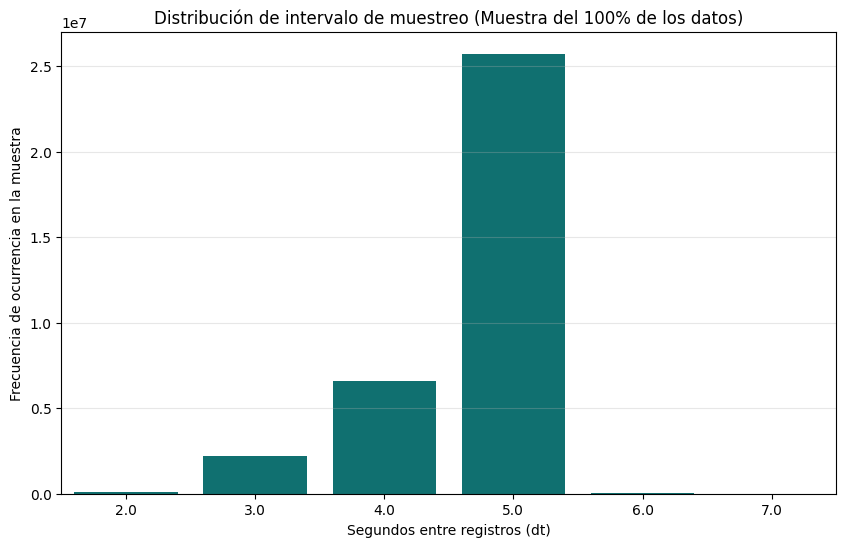


Media de latencia: 4.68s
Desviación estándar: 0.60s


In [21]:
if todos_los_deltas_sanos:
    fraccion_visualizacion = 1.0

    # Tomamos una muestra aleatoria del vector ya calculado
    datos_para_graficar = random.sample(todos_los_deltas_sanos, int(len(todos_los_deltas_sanos) * fraccion_visualizacion))
    
    # Graficamos con la muestra reducida
    plt.figure(figsize=(10, 6))
    ax = sns.countplot(x=pd.Series(datos_para_graficar), color='teal')
    
    plt.title(f'Distribución de intervalo de muestreo (Muestra del {int(fraccion_visualizacion*100)}% de los datos)')
    plt.xlabel('Segundos entre registros (dt)')
    plt.ylabel('Frecuencia de ocurrencia en la muestra')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    print(f"\nMedia de latencia: {np.mean(datos_para_graficar):.2f}s")
    print(f"Desviación estándar: {np.std(datos_para_graficar):.2f}s")

In [29]:
# 1. Creamos la estructura base con todas las ejecuciones (1740 filas)
df_alineacion = pd.DataFrame(lista_execution_name, columns=['execution_name'])

# 2. Convertimos el diccionario 'data' (que solo contiene las con problemas) a un DataFrame
df_problemas = pd.DataFrame(data) 

# 3. Hacemos un 'left join'. 
# Si el execution_name está en df_problemas, se trae los datos; si no, deja NaN.
df_alineacion = df_alineacion.merge(df_problemas, on='execution_name', how='left')

# 4. Rellenamos los huecos (NaN) para ejecuciones sin problemas:
# - num_desalineadas a 0 (y convertimos a entero)
# - metricas_desalineadas a cadena vacía
df_alineacion['num_desalineadas'] = df_alineacion['num_desalineadas'].fillna(0).astype(int)
df_alineacion['metricas_desalineadas'] = df_alineacion['metricas_desalineadas'].fillna('')

# Resultado: Tu tabla completa de auditoría de datos
df_alineacion[df_alineacion['num_desalineadas']!=0]

,execution_name,num_desalineadas,metricas_desalineadas
803,light-oauth2-data-1722514683.tar,103,"go_gc_duration_seconds_count, go_gc_duration_s..."


In [31]:
df_alineacion.to_parquet(f'{FOLDER_SALIDA}/df_alineacion.parquet', index=False,engine='fastparquet')

# <span style="color:#2ca02c">7. Analisis de datos no numericos que se repiten en ejecucion/metrica
</span>

In [11]:
set_descartadas = set(lista_ejecuciones_descartadas)
lista_ejecuciones_sel = [x for x in lista_execution_name if x not in set_descartadas]

In [12]:
len(lista_ejecuciones_sel)

1732

In [14]:
len(lista_metricas_sel)

117

In [19]:
tuple_ejecuciones=(lista_ejecuciones_sel[0],)
tuple_metricas = (lista_metricas_sel[0],)
print(tuple_ejecuciones)
print(tuple_metricas)

('light-oauth2-data-1719592986.tar',)
('go_gc_duration_seconds',)


In [20]:



# for una_ejecucion in lista_ejecuciones_sel:
#     for una_metrica in lista_metricas_sel:
#tuple_ejecuciones = tuple(lista_ejecuciones_sel)
tuple_metricas = tuple(lista_metricas_sel)

SQL = """
    SELECT execution_name, metric_name, instance, grupo, job, tags, count(*) as N
    FROM metricas 
    -- WHERE 
    --  execution_name IN %s 
    --  AND metric_name IN %s
    GROUP BY execution_name, metric_name, instance, grupo, job, tags
    -- Opcional: LIMIT 1000 
"""

df = pd.read_sql(SQL, engine, params=(tuple_ejecuciones, tuple_metricas))


In [65]:
SALIR=False
N_execution=0
resultados_acumulados = []
for una_ejecucion in lista_ejecuciones_sel:
    N_execution+=1
    for una_metrica in lista_metricas_sel:
        print(f'execution_name={una_ejecucion} N_ex={N_execution:4d} metric_name={una_metrica}'.ljust(200), end='\r')
        
        SQL = """
            SELECT execution_name, metric_name, instance, grupo, job, tags
            FROM metricas 
            WHERE 
              execution_name=%s 
              AND metric_name= %s
        """
        df = pd.read_sql(SQL, engine, params=(una_ejecucion, una_metrica))
        columnas_a_limpiar = ['grupo', 'job', 'instance']
        for col in columnas_a_limpiar:
            df[col] = df[col].fillna("None")
        # Crea un nuevo DataFrame con las combinaciones únicas y su conteo


        df['tags_str'] = df['tags'].apply(lambda x: str(x) if x is not None else "None")
        df_combinaciones = df.groupby(['execution_name', 'metric_name', 'instance', 'grupo', 'job']).agg(N=('execution_name', 'size'), N_tags=('tags_str', 'nunique')).reset_index()
        resultados_acumulados.append(df_combinaciones)
        
    #     if len(df_combinaciones)>1:  
    #         SALIR=True
    #         display(df)
    #         display(df_combinaciones)
    #     if SALIR:
    #         break
    # if SALIR:
    #     break
    df_execution_metric = pd.concat(resultados_acumulados, ignore_index=True)


execution_name=light-oauth2-data-1725869703.tar N_ex=1732 metric_name=prometheus_engine_query_duration_seconds                                                                                          

In [67]:
df_execution_metric=df_final

In [69]:
df_execution_metric[df_execution_metric['N_tags']!=1]

,execution_name,metric_name,instance,grupo,job,N,N_tags
93537,light-oauth2-data-1722514683.tar,node_network_iface_id,node_exporter:9100,production,node,172,2
93538,light-oauth2-data-1722514683.tar,node_network_iface_link,node_exporter:9100,production,node,172,2


In [70]:
df_execution_metric_analisis = df_execution_metric[['execution_name','metric_name','instance','grupo','job'] ].groupby(['execution_name', 'metric_name']).size().reset_index(name='n_combinaciones_distintas')

In [72]:
df_execution_metric_analisis[   df_execution_metric_analisis['n_combinaciones_distintas']!=1  ]

,execution_name,metric_name,n_combinaciones_distintas


Se observa que para una ejecucion/metrica los datos de job, grupo,instance se repiten en toda esa serie.

In [73]:
df_execution_metric.to_parquet(f'{FOLDER_SALIDA}/df_execution_metric.parquet', index=False,engine='fastparquet')
df_execution_metric_analisis.to_parquet(f'{FOLDER_SALIDA}/df_execution_metric_analisis.parquet', index=False,engine='fastparquet')

# <span style="color:#2ca02c">8. Interpolacion de series</span>

In [19]:
def obtener_datos_ejecucion_metrica(execution_name, metric_name, engine):
    """
    Extrae todos los registros de una ejecución y métrica específica.
    """
    SQL = """
        SELECT time,instance,grupo,job,tags,label,metric_value
        FROM metricas 
        WHERE execution_name = %s 
          AND metric_name = %s
        ORDER BY time ASC
    """
    
    # Ejecutamos la consulta pasando los parámetros de forma segura
    df = pd.read_sql(SQL, engine, params=(execution_name, metric_name))
    
    # Convertimos la columna time a formato datetime
    df['time'] = pd.to_datetime(df['time'])
    df         = df.sort_values('time')


    inicio_global = df['time'].min()
    df['tiempo_relativo'] = (df['time'] - inicio_global).dt.total_seconds()
        
    return df


In [216]:
set_descartadas = set(lista_ejecuciones_descartadas)
lista_ejecuciones_sel = [x for x in lista_execution_name if x not in set_descartadas]

In [218]:
una_ejecucion=lista_ejecuciones_sel[160]


In [21]:
def interpolar(df_serie,INTERVALO_VALOR):
    
    # --- 1. CONFIGURACIÓN ---
    INTERVALO_VALOR = 5
    INTERVALO_MUESTREO = f'{INTERVALO_VALOR}s'
    
    # --- 2. PREPARACIÓN ---
    # Aseguramos que 'time' es datetime y ordenamos
    df_serie['time'] = pd.to_datetime(df_serie['time'])
    df_serie = df_serie.sort_values('time')
    
    # Filtramos solo las columnas que nos interesan
    cols_a_mantener = ['time', 'metric_value', 'grupo', 'instance', 'job', 'label','tags']
    cols_numericas = ['metric_value']  # Ajusta si tienes más columnas numéricas
    cols_texto = ['grupo', 'instance', 'job', 'label', 'tags']
    
    df_filtrado = df_serie[cols_a_mantener].copy()
    df_filtrado['metric_value'] = df_filtrado['metric_value'].astype(float)
    
    # --- 3. PROCESAMIENTO ---
    # Establecemos el índice temporal
    df_indexado = df_filtrado.set_index('time').sort_index()
    
    # AJUSTE: Calculamos el final redondeando al siguiente múltiplo de 5 segundos
    # Esto asegura que si tu último punto es 799, el rango llegue hasta 800
    inicio = df_indexado.index.min()
    ultimo_timestamp = df_indexado.index.max()
    # Calculamos cuánto falta para el siguiente múltiplo de 5s
    segundos_faltantes = INTERVALO_VALOR - (ultimo_timestamp.second % INTERVALO_VALOR)
    fin = df_indexado.index.max().ceil(INTERVALO_MUESTREO) + pd.Timedelta(seconds=INTERVALO_VALOR)
    
    
    rango_muestreo = pd.date_range(start=inicio, end=fin, freq=INTERVALO_MUESTREO)
    
    # Creamos un DataFrame destino con el índice regular
    df_target = pd.DataFrame(index=rango_muestreo)
    
    df_fusionado = df_target.join(df_indexado, how='outer')
    df_fusionado[cols_numericas] = df_fusionado[cols_numericas].interpolate(method='time')
    df_fusionado[cols_texto] = df_fusionado[cols_texto].ffill()
    df_final = df_fusionado.loc[df_target.index]
    inicio_global = df_final.index.min()
    df_final['tiempo_relativo'] = (df_final.index - inicio_global).total_seconds()
    return df_final


In [18]:
def plot_serie_temporal(ax, df_serie, df_final, una_ejecucion, una_metrica):
    """Dibuja el gráfico en un objeto axes proporcionado."""
    ax.plot(df_serie['tiempo_relativo'], df_serie['metric_value'], 
            'o-', label='Serie Original', color='blue', alpha=0.6, markersize=4)
    ax.plot(df_final['tiempo_relativo'], df_final['metric_value'], 
            '--', label='Serie Interpolada (5s)', color='red', alpha=0.8)
    
    ax.set_title(f'Serie Temporal Original vs. Interpolada (Muestreo 5s)\nexecution_name = {una_ejecucion}\nmetric_name = {una_metrica}')
    ax.set_xlabel('Tiempo Relativo (segundos)')
    ax.set_ylabel('Valor')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

In [224]:
INTERVALO_MUESTREO=5
with PdfPages(f'{FOLDER_SALIDA}/serie_original_e_interpolada.pdf') as pdf:
    for una_metrica in lista_metricas_sel:
        print(f'execution_name = {una_ejecucion}   |  metric_name = {una_metrica}'.ljust(200),end='\r')
        df_serie        = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
        df_interpolado=interpolar(df_serie,INTERVALO_MUESTREO)

        fig, ax = plt.subplots(figsize=(11.69, 8.27)) # Tamaño A4 apaisado
        
        # Llamamos a la función de dibujo
        plot_serie_temporal(ax, df_serie, df_interpolado, una_ejecucion, una_metrica)
        
        # --- GUARDADO EN PDF ---
        pdf.savefig(fig, orientation='landscape')
        
        # --- OPCIONAL: MOSTRAR EN PANTALLA ---
        # display(fig) 
        
        plt.close(fig) # IMPORTANTE: cerrar para liberar memoria

execution_name = light-oauth2-data-1720167247.tar   |  metric_name = prometheus_engine_query_duration_seconds                                                                                           

# <span style="color:#2ca02c">9. Detección de outliers</span>

## <span style="color:#2ca02c">9a. Detección de outliers revsando métricas aisladas</span>

In [31]:
#recuperamos datos para indentificar datos outliers
with open('result/lista_ejecuciones_descartadas.json', "r", encoding="utf-8") as f:
    lista_ejecuciones_descartadas = json.load(f)
    set_descartadas = set(lista_ejecuciones_descartadas)
    lista_ejecuciones_sel = [x for x in lista_execution_name if x not in set_descartadas]
df_analisis_metricas = pd.read_parquet(f'{FOLDER_SALIDA}/analisis_metricas.parquet', engine='fastparquet')
lista_metricas_sel=df_analisis_metricas[   df_analisis_metricas['metric_name_sel']!=''  ]['metric_name'].tolist()
lista_metricas_sel.append('prometheus_engine_query_duration_seconds')

In [44]:
una_metrica    = lista_metricas_sel[1]

In [45]:
print('=============')
df_filtrado = df_analisis_metricas[  df_analisis_metricas['metric_name']==una_metrica   ]
clasificacion = df_filtrado.iloc[0]['clasificacion']
metric_name_sel = df_filtrado.iloc[0]['metric_name_sel']
display(df_filtrado)
print(f'clasificacion   = {clasificacion}')
print(f'metric_name_sel = {metric_name_sel}')

,metric_name,std_dev_nulo,valores_NAN,metrica_monotona,diff_invariante,clasificacion,metric_name_sel,redundante
1,go_gc_duration_seconds_count,False,False,True,False,diff,go_gc_duration_seconds_count_diff,False


clasificacion   = diff
metric_name_sel = go_gc_duration_seconds_count_diff


In [46]:
#Revisamos cuantas muestras tienen los datos 'correct' de cada ejecucion de una de las metricas

INTERVALO_MUESTREO = 5
lista_series=[]
N=0
for una_ejecucion in lista_ejecuciones_sel:
    N+=1
    print(f'execution_name = {una_ejecucion}   | N={N:04d}  | metric_name = {una_metrica}'.ljust(200),end='\r')
    df_serie       = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
    df_interpolado = interpolar(df_serie,INTERVALO_MUESTREO)
    df_interpolado_correct=df_interpolado[  df_interpolado['label']=='correct'  ]
    lista_valores_tmp = df_interpolado_correct['metric_value'].tolist()
    lista_series.append(lista_valores_tmp)

print()
print('=================')
longitudes = [len(serie) for serie in lista_series]

todos_los_valores = [valor for serie in lista_series for valor in serie]

# 2. Contamos cuántas veces aparece cada longitud
conteo_longitudes = Counter(longitudes)

# 3. Imprimimos el resultado de forma ordenada
print("Distribución de longitudes de las series:")
for longitud in sorted(conteo_longitudes.keys()):
    print(f"Longitud {longitud}: {conteo_longitudes[longitud]} ejecuciones")

execution_name = light-oauth2-data-1725869703.tar   | N=1732  | metric_name = go_gc_duration_seconds_count                                                                                              
Distribución de longitudes de las series:
Longitud 13: 1731 ejecuciones
Longitud 15: 1 ejecuciones


<span style="color:#2ca02c">Todas las ejecuciones tienen 13 muestras salvo una, usaremos solo  las de 13 para descartar outliers</span>

In [74]:
longitud_correct=13
INTERVALO_MUESTREO=5
nombre_pdf = "result/visualizacion_outliers.pdf"
N_metrica=0
with PdfPages(nombre_pdf) as pdf:
    for i, una_metrica in enumerate(lista_metricas_sel, 1):
        N_metrica+=1
        df_sel = df_analisis_metricas[df_analisis_metricas['metric_name'] == una_metrica]
        clasificacion = df_sel.iloc[0]['clasificacion']
        metric_name_sel = df_sel.iloc[0]['metric_name_sel']

        lista_series = []
        # 1. Recolectamos todas las series PRIMERO
        for N, una_ejecucion in enumerate(lista_ejecuciones_sel, 1):
            print(f'Procesando: {una_metrica} | Ejecucción: {N:04d}/{len(lista_ejecuciones_sel)}   | N_Metrica: {N_metrica:04d}', end='\r')
            
            df_serie = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
            df_interpolado = interpolar(df_serie, INTERVALO_MUESTREO)
            lista_valores_tmp = df_interpolado[df_interpolado['label'] == 'correct']['metric_value'].tolist()

            
            lista_series.append(lista_valores_tmp[:longitud_correct])

        # 2. Creamos el DataFrame fuera del bucle de ejecuciones
        df = pd.DataFrame(lista_series)
        
        # Aplicar diff si corresponde
        if clasificacion == 'diff':
            df = df.diff(axis=1).dropna(axis=1)

        # 3. Centrado
        df_centrado = df.sub(df.mean(axis=1), axis=0)

        # 4. Generación del gráfico y guardado en PDF
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)
        
        # Gráficos... (mantiene tu lógica anterior usando ax1 y ax2)
        ax1.plot(df.T, color='gray', alpha=0.1, linewidth=1)
        ax1.plot(df.mean(axis=0), color='red', linewidth=2)
        ax1.set_title(f"Valores Absolutos: {metric_name_sel}")
        ax1.grid(True, axis='x', linestyle='--', alpha=0.3)
        
        ax2.plot(df_centrado.T, color='gray', alpha=0.1, linewidth=1)
        ax2.plot(df_centrado.mean(axis=0), color='blue', linewidth=2)
        ax2.set_title(f"Series Centradas: {metric_name_sel}")
        ax2.grid(True, axis='x', linestyle='--', alpha=0.3)

        plt.tight_layout()
        pdf.savefig(fig) # GUARDAR EN PDF
        plt.close(fig)   # Liberar memoria importante
        #print(f"\nGráfico para {una_metrica} guardado en PDF.")

Procesando: go_gc_duration_seconds | Ejecucción: 0403/1732   | N_Metrica: 0001

KeyboardInterrupt: 

In [117]:
longitud_correct=13
INTERVALO_MUESTREO=5
lista_outliers=[]
nombre_pdf = "result/visualizacion_outliers.pdf"
N_metrica=0
with PdfPages(nombre_pdf) as pdf:
    for i, una_metrica in enumerate(lista_metricas_sel, 1):
        N_metrica+=1
        df_sel = df_analisis_metricas[df_analisis_metricas['metric_name'] == una_metrica]
        clasificacion = df_sel.iloc[0]['clasificacion']
        metric_name_sel = df_sel.iloc[0]['metric_name_sel']

        lista_series = []
        # 1. Recolectamos todas las series PRIMERO
        for N, una_ejecucion in enumerate(lista_ejecuciones_sel, 1):
            print(f'Procesando: {una_metrica} | Ejecucción: {N:04d}/{len(lista_ejecuciones_sel)}   | N_Metrica: {N_metrica:04d}', end='\r')
            
            df_serie = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
            df_interpolado = interpolar(df_serie, INTERVALO_MUESTREO)
            lista_valores_tmp = df_interpolado[df_interpolado['label'] == 'correct']['metric_value'].tolist()
            
            # if len(lista_valores_tmp) == 13:
            #     lista_series.append(lista_valores_tmp)
            lista_series.append(lista_valores_tmp[:longitud_correct])                

        # 2. Creamos el DataFrame fuera del bucle de ejecuciones
        df = pd.DataFrame(lista_series)
        
        # Aplicar diff si corresponde
        if clasificacion == 'diff':
            df = df.diff(axis=1).dropna(axis=1)

        # 3. Centrado
        df_centrado = df.sub(df.mean(axis=1), axis=0)

        # 4. Generación del gráfico y guardado en PDF
        fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 10), sharex=True)
        
        # Gráficos... (mantiene tu lógica anterior usando ax1 y ax2)
        ax1.plot(df.T, color='gray', alpha=0.1, linewidth=1)
        ax1.plot(df.mean(axis=0), color='red', linewidth=2)
        ax1.set_title(f"Valores Absolutos: {metric_name_sel}")
        ax1.grid(True, axis='x', linestyle='--', alpha=0.3)
        
        ax2.plot(df_centrado.T, color='gray', alpha=0.1, linewidth=1)
        ax2.plot(df_centrado.mean(axis=0), color='blue', linewidth=2)
        ax2.set_title(f"Series Centradas: {metric_name_sel}")
        ax2.grid(True, axis='x', linestyle='--', alpha=0.3)

        plt.tight_layout()
        pdf.savefig(fig) # GUARDAR EN PDF
        plt.close(fig)   # Liberar memoria importante

        #calculamos desviaciones y marcaremos reires que se desvian demasiado del promedio para marcarlas como outliers
        desviacion_global = df_centrado.stack().std()
        umbral_real = 3 * desviacion_global
        outliers = df_centrado[(df_centrado.abs() > umbral_real).any(axis=1)] 
        list_index_outlier=df_centrado[(df_centrado.abs() > umbral).any(axis=1)].index.tolist()   #identificamos las ejecuciones como outlier si alguno de sus puntos se desvia demasaido el promedio
        for index_outlier in list_index_outlier:
            reg_outlier={}
            reg_outlier['execution_name'] = lista_ejecuciones_sel[index_outlier]
            reg_outlier['metric_name']    = una_metrica
            lista_outliers.append(reg_outlier)
            
        # if N_metrica>=5:
        #     break


Procesando: prometheus_engine_query_duration_seconds | Ejecucción: 1732/1732   | N_Metrica: 01176 01027a: 0094

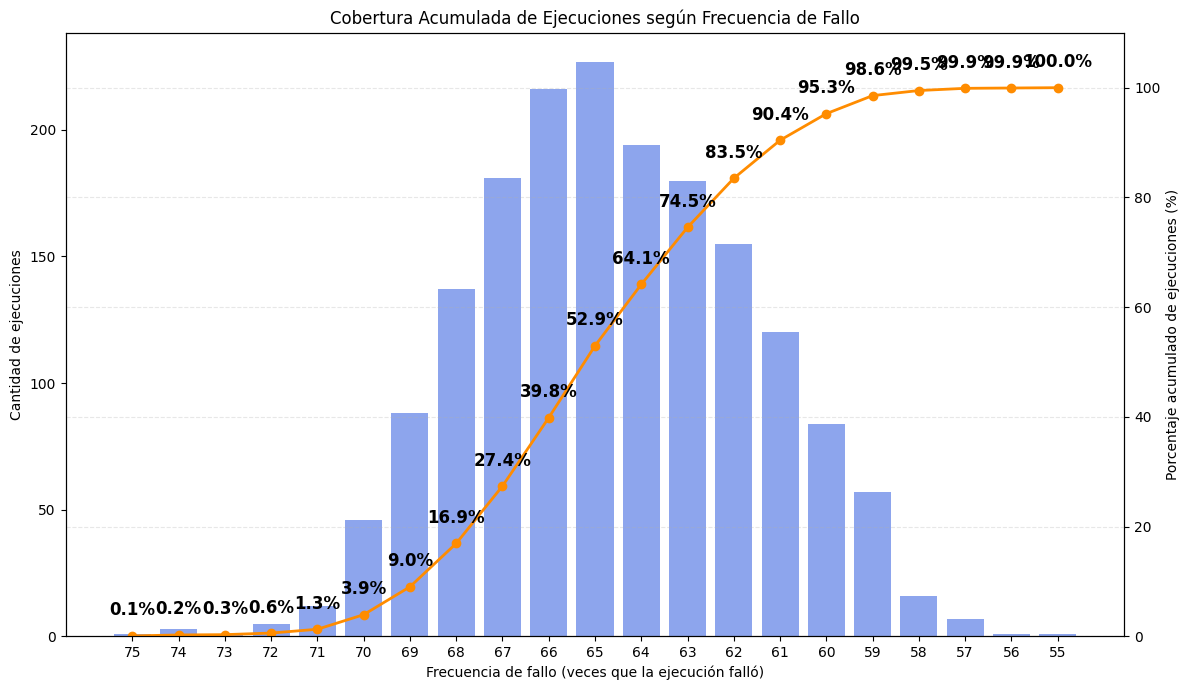

In [125]:
df_outliers=pd.DataFrame(lista_outliers)

conteo_por_ejecucion = df_outliers['execution_name'].value_counts()
df_conteo_outliers = conteo_por_ejecucion.reset_index()
df_conteo_outliers.columns = ['execution_name', 'N_anomalias']

distribucion = conteo_por_ejecucion.value_counts().sort_index(ascending=False)

df_cobertura = pd.DataFrame({'num_ejecuciones': distribucion})
df_cobertura['total_ejecuciones'] = df_cobertura['num_ejecuciones'].sum()

df_cobertura['porcentaje_cobertura_ejecuciones'] = (df_cobertura['num_ejecuciones'].cumsum() / df_cobertura['total_ejecuciones']) * 100

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.bar(df_cobertura.index.astype(str), df_cobertura['num_ejecuciones'], color='royalblue', alpha=0.6)
ax1.set_xlabel('Frecuencia de fallo (veces que la ejecución falló)')
ax1.set_ylabel('Cantidad de ejecuciones')
ax1.set_title('Cobertura Acumulada de Ejecuciones según Frecuencia de Fallo')


ax2 = ax1.twinx()
ax2.plot(df_cobertura.index.astype(str), df_cobertura['porcentaje_cobertura_ejecuciones'], 
         color='darkorange', marker='o', linewidth=2)
ax2.set_ylabel('Porcentaje acumulado de ejecuciones (%)')
ax2.set_ylim(0, 110)

for i, txt in enumerate(df_cobertura['porcentaje_cobertura_ejecuciones']):
    ax2.text(i, txt + 3, f'{txt:.1f}%', ha='center', va='bottom', 
             fontsize=12, fontweight='bold', color='black')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [128]:
umbral_metricas_con_anomalia=71
df_conteo_outliers['Outlier']=df_conteo_outliers['N_anomalias']>=umbral_metricas_con_anomalia

In [130]:
df_conteo_outliers[df_conteo_outliers['Outlier']]

,execution_name,N_anomalias,Outlier
0,light-oauth2-data-1723824878.tar,75,True
1,light-oauth2-data-1724372083.tar,74,True
2,light-oauth2-data-1721812449.tar,74,True
3,light-oauth2-data-1723245286.tar,74,True
4,light-oauth2-data-1723004055.tar,73,True
5,light-oauth2-data-1719965648.tar,72,True
6,light-oauth2-data-1724379281.tar,72,True
7,light-oauth2-data-1721139242.tar,72,True
8,light-oauth2-data-1722640462.tar,72,True
9,light-oauth2-data-1724998477.tar,72,True


In [131]:
df_outliers.to_parquet(f'{FOLDER_SALIDA}/df_outliers.parquet', index=False,engine='fastparquet')
df_conteo_outliers.to_parquet(f'{FOLDER_SALIDA}/df_conteo_outliers.parquet', index=False,engine='fastparquet')

## <span style="color:#2ca02c">9b. Detección de outliers con análisis PCA</span>

In [38]:
INTERVALO_MUESTREO=5
df_analisis_metricas = pd.read_parquet(f'{FOLDER_SALIDA}/analisis_metricas.parquet')
lista_metricas_sel=df_analisis_metricas[   df_analisis_metricas['metric_name_sel']!=''  ]['metric_name'].tolist()
lista_metricas_sel.append('prometheus_engine_query_duration_seconds')

In [39]:
set_descartadas = set(lista_ejecuciones_descartadas)
lista_ejecuciones_sel = [x for x in lista_execution_name if x not in set_descartadas]

In [40]:
len(lista_ejecuciones_sel)

1732

In [41]:
# --- Configuración ---
lista_de_dfs = []
longitud_correct = 13


for una_metrica in lista_metricas_sel:
    df_sel = df_analisis_metricas[df_analisis_metricas['metric_name'] == una_metrica]
    clasificacion = df_sel.iloc[0]['clasificacion']
    
    lista_series = []
    for una_ejecucion in lista_ejecuciones_sel:
        df_serie = obtener_datos_ejecucion_metrica(una_ejecucion, una_metrica, engine)
        df_interpolado = interpolar(df_serie, INTERVALO_MUESTREO)
        lista_valores_tmp = df_interpolado[df_interpolado['label'] == 'correct']['metric_value'].tolist()
        lista_series.append(lista_valores_tmp[:longitud_correct])

    # Construir el DF de esta métrica
    df_metric = pd.DataFrame(lista_series, index=lista_ejecuciones_sel)
    
    if clasificacion == 'diff':
        df_metric = df_metric.diff(axis=1).iloc[:, 1:]
    
    df_metric.columns = [f"{una_metrica}_t{t}" for t in range(df_metric.shape[1])]
    
    # Acumular
    lista_de_dfs.append(df_metric)
    print(f"Procesada métrica: {una_metrica}", end='\r')

# --- Construcción final única ---
df_limpio = pd.concat(lista_de_dfs, axis=1)
df_limpio = df_limpio.fillna(df_limpio.median())

print(f"\nProceso terminado. Dataset listo con {df_limpio.shape[1]} variables.")

KeyboardInterrupt: 

In [ ]:
df_limpio.to_parquet(f'{FOLDER_SALIDA}/df_limpio.parquet', index=False,engine='fastparquet')

In [42]:
#df_limpio = pd.read_parquet(f'{FOLDER_SALIDA}/df_limpio.parquet')

In [43]:
# 1. Eliminar columnas que tienen TODOS sus valores como NaN
df_limpio = df_limpio.dropna(axis=1, how='all')

# 2. Identificar columnas constantes (incluso si tienen NaNs mezclados)
# Usamos dropna=False para que considere NaNs como un valor único
cols_constantes = [col for col in df_limpio.columns if df_limpio[col].nunique(dropna=True) <= 1]

if cols_constantes:
    print(f"Eliminando {len(cols_constantes)} columnas constantes/vacías.")
    df_limpio = df_limpio.drop(columns=cols_constantes)

# 3. Imputar los valores faltantes (NaNs restantes)
# Si te queda algún hueco, usamos la mediana de la columna
df_limpio = df_limpio.fillna(df_limpio.median())

# 4. Verificación final (¡IMPORTANTE!)
if df_limpio.isnull().values.any():
    print("¡AVISO! Todavía hay NaNs en el DataFrame. Limpiando filas completas...")
    df_limpio = df_limpio.dropna()

# 5. Ahora sí, escalar
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_limpio)

# 6. Aplicar PCA
# Seleccionamos componentes para retener el 95% de la varianza
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(df_scaled)


# 7. Reconstrucción
# Intentamos volver al espacio original desde los componentes principales
df_reconstruido = pca.inverse_transform(pca_data)



# 8. Calcular el Error de Reconstrucción (MSE) por fila (ejecución)
# Esto nos dice qué tan "diferente" es la ejecución real respecto a lo que el PCA aprendió
mse = ((df_scaled - df_reconstruido) ** 2).mean(axis=1)


# Añadimos el error al DataFrame original para identificar los outliers
df_outliers_pca = pd.DataFrame({'mse': mse}, index=df_limpio.index)
df_outliers_pca['execution_name'] = lista_ejecuciones_sel


Eliminando 318 columnas constantes/vacías.


In [45]:

# Usamos el criterio de 3 desviaciones sobre el MSE, o un percentil (ej: percentil 99)
umbral_pca = df_outliers_pca['mse'].mean() + (3 * df_outliers_pca['mse'].std())
df_ejecuciones_outlier = df_outliers_pca[df_outliers_pca['mse'] > umbral_pca]


print(f"Se han identificado {len(df_ejecuciones_outlier)} ejecuciones como outliers basándose en el PCA.")

Se han identificado 27 ejecuciones como outliers basándose en el PCA.


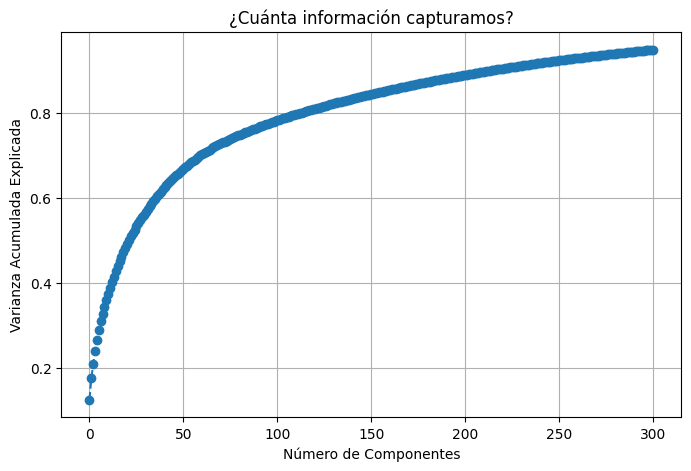

In [166]:
plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.title('¿Cuánta información capturamos?')
plt.grid(True)
plt.show()

In [167]:
varianza_total = pca.explained_variance_ratio_.sum()
print(f"Varianza total explicada por estos componentes: {varianza_total:.2%}")
print(f'Número de componentes :   {pca.n_components_}')


Varianza total explicada por estos componentes: 95.01%
Número de componentes :   301


In [47]:
df_outliers_pca.to_parquet(f'{FOLDER_SALIDA}/df_outliers_pca.parquet', index=False,engine='fastparquet')
df_ejecuciones_outlier.to_parquet(f'{FOLDER_SALIDA}/df_ejecuciones_outlier.parquet', index=False,engine='fastparquet')

1732